### Read 2D map

In [9]:
import numpy as np
import imageio.v3 as imageio
import matplotlib.pyplot as plt

In [10]:
arr = (imageio.imread("polygons2.png") > 0).astype(np.uint8)

In [11]:
print(arr.shape)
print(arr[:25, :25])

(100, 100)
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

# Task 1: If path exist?

Assumptions: The map only contains 2D polygon obstacles.

So, we can use visibility graph to find out corners of ploygons, then search path by corners.

1. find polygon corners of all obstavles
2. build a visibility graph
3. run BFS

In [12]:
def find_corners(universe: np.ndarray) -> list[tuple[int, int]]:
    '''Find convex corners of the obstacles.

    example:
    0 0 1     . . x
    0 1 0  => . P .
    0 0 0     . . .

    . = free, P = free corner, x = obstacle
    '''
    w, h = universe.shape
    obs = universe.astype(bool)
    free = ~obs

    P = np.pad(obs, 1, mode="constant", constant_values=False)
    NW = P[0:w, 0:h]
    N  = P[1:w+1,   0:h]
    NE = P[2:w+2,   0:h]
    W  = P[0:w, 1:h+1]
    E  = P[0:w, 2:h+2]
    SW = P[0:w, 2:h+2]
    S  = P[2:w+2, 1:h+1]
    SE = P[2:w+2, 2:h+2]
    corner = free & ((NW & ~N & ~W) | (NE & ~N & ~E) | (SW & ~S & ~W) | (SE & ~S & ~E))
    ys, xs = np.where(corner)
    return list(zip(xs.tolist(), ys.tolist()))

In [13]:
def is_reachable(universe, x0, y0, x1, y1) -> bool:
    '''Check if start and end are in the same connected component of free space.'''
    W, H = universe.shape
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = 1 if x0 < x1 else -1    # step direction in x
    sy = 1 if y0 < y1 else -1    # step direction in y
    err = dx - dy
    x, y = x0, y0

    while True:
        # out of bounds or obstacle
        if not (0 <= x < W and 0 <= y < H) or universe[x, y] == 1:   
            return False
        if x == x1 and y == y1:    # reached destination
            return True

        err2 = err * 2  # Bresenham's line algorithm
        if err2 > -dy:  # step in x direction
            err -= dy
            x += sx
        if err2 < dx:   # step in y direction
            err += dx
            y += sy 


In [14]:
from collections import deque

def path_exists(
        universe: np.ndarray, 
        start: tuple[int, int], 
        end: tuple[int, int],
        visualize: bool = False) -> bool:
    '''Check if path exists from start to end in the map
    1. Find all corners of obstacle
    2. Build visibility graph using corners
    3. BFS find path
    '''
    W, H = universe.shape
    start_x, start_y = start
    end_x, end_y = end

    def show(path):    # draw map + start/end, plus path if found
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(universe, cmap="gray_r", origin="upper")
        if path is not None:
            xs = [p[0] for p in path]
            ys = [p[1] for p in path]
            ax.plot(ys, xs, c="cyan", lw=2, marker="o", ms=4, zorder=2, label=f"path ({len(path)} nodes)")
            ax.set_title("path found")
        else:
            ax.set_title("no path")
        ax.scatter(start_y, start_x, c="lime", s=120, marker="o", edgecolors="black", label=f"start {start}", zorder=3)
        ax.scatter(end_y,   end_x,   c="red",  s=120, marker="X", edgecolors="black", label=f"end {end}",     zorder=3)
        ax.set_xlabel("y (col)")
        ax.set_ylabel("x (row)")
        ax.legend(loc="upper right")
        plt.show()

     # start and end are the same point
    if (start_x, start_y) == (end_x, end_y):   
        if visualize: show([start])
        return True
    for x, y in [(start_x, start_y), (end_x, end_y)]:
        # out of bounds or obstacle
        if not (0 <= x < W and 0 <= y < H) or universe[x, y] == 1:    
            if visualize: show(None)
            return False

    nodes = [(start_x, start_y), (end_x, end_y)]
    nodes += find_corners(universe)
    
    seen, uniq = set(), []
    for nd in nodes:
        if nd not in seen:
            seen.add(nd)
            uniq.append(nd)
    
    nodes = uniq
    n = len(nodes)

    # BFS
    START, END = 0, 1
    visited = [False] * n
    parent  = [-1]    * n    # for path reconstruction when visualize=True
    visited[START] = True
    q = deque([START])

    while q:
        u = q.popleft()
        if u == END:
            if visualize:
                path, cur = [], END
                while cur != START:
                    path.append(nodes[cur])
                    cur = parent[cur]
                path.append(nodes[START])
                path.reverse()
                show(path)
            return True

        ux, uy = nodes[u]
        for v in range(n):
            if visited[v]:
                continue
            vx, vy = nodes[v]
            if is_reachable(universe, ux, uy, vx, vy):
                visited[v] = True
                parent[v]  = u
                q.append(v)
    if visualize: show(None)
    return False

# Task 1 & 2 Results:
1. Find a path if it exists
2. Plot the found path

## Positive cases

0 0


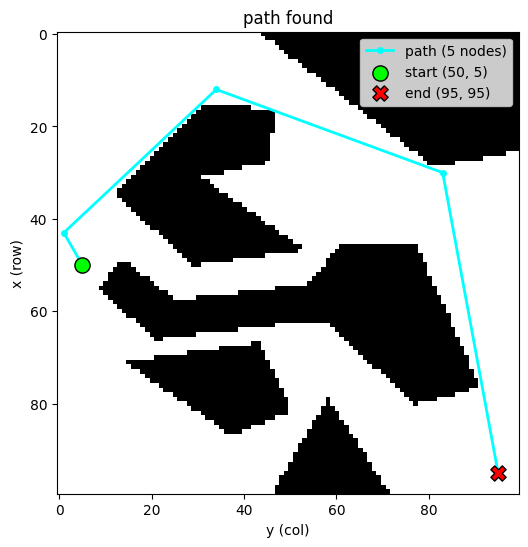

True

In [15]:
arr = (imageio.imread("polygons1.png") > 0).astype(np.uint8)
start = (50, 5)
end = (95, 95)

print(arr[start], arr[end])
path_exists(arr, start, end, visualize=True)

0 0


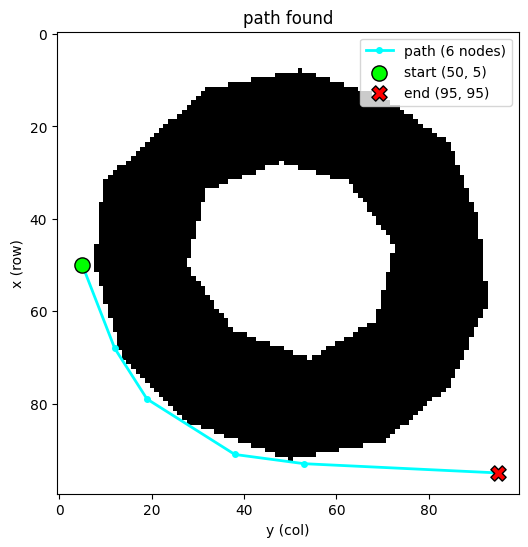

True

In [22]:
arr = (imageio.imread("polygons2.png") > 0).astype(np.uint8)
start = (50, 5)
end = (95, 95)

print(arr[start], arr[end])
path_exists(arr, start, end, visualize=True)

## Negative cases

### a. End point is inside an obstacle


0 1


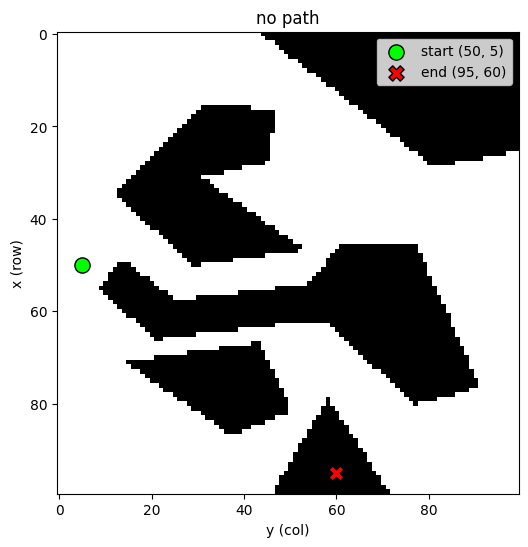

False

In [ ]:
arr = (imageio.imread("polygons1.png") > 0).astype(np.uint8)
start = (50, 5)
end = (95, 60)

print(arr[start], arr[end])
path_exists(arr, start, end, visualize=True)

0 0


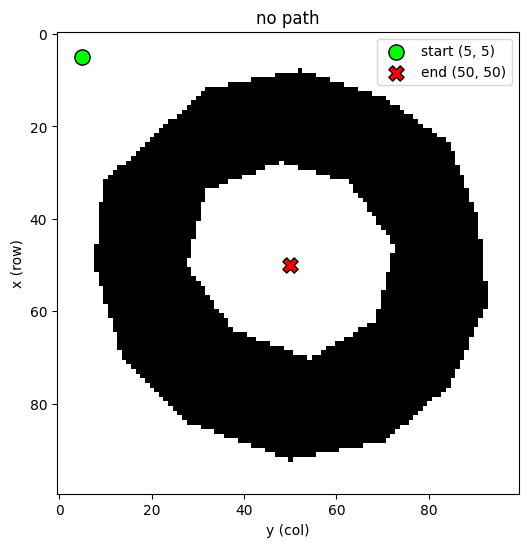

False

In [16]:
arr = (imageio.imread("polygons2.png") > 0).astype(np.uint8)
start = (5, 5)
end = (50, 50)

print(arr[start], arr[end])
path_exists(arr, start, end, visualize=True)